In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.ensemble import HistGradientBoostingRegressor

# ── Load data ─────────────────────────────────────────────────────────────────
df_interval = pd.read_csv('./data/C - Interval.csv', index_col=0)
df_daily    = pd.read_csv('./data/C - Daily.csv', index_col=0)

# ── Prep daily data ───────────────────────────────────────────────────────────
df_daily['Date'] = pd.to_datetime(df_daily['Date'].str[:8], format='%m/%d/%y')
df_daily = df_daily.sort_values('Date').reset_index(drop=True)

df_daily['day_of_week']  = df_daily['Date'].dt.dayofweek
df_daily['month']        = df_daily['Date'].dt.month
df_daily['day_of_month'] = df_daily['Date'].dt.day

for col in ['Call Volume', 'CCT', 'Abandon Rate']:
    df_daily[col] = df_daily.groupby('day_of_week')[col].transform(
        lambda x: x.fillna(x.median())
    )

# ── Prep interval data ────────────────────────────────────────────────────────
start = '2025-04-01 00:00:00'
end   = '2025-06-30 23:30:00'
dr    = pd.date_range(start=start, end=end, freq='30min')

df_base = pd.DataFrame({
    'Month':           pd.Series(dr).dt.month_name(),
    'Day':             pd.Series(dr).dt.day,
    'Interval':        pd.Series(dr).dt.strftime('%H:%M:%S'),
    'Day of the Week': pd.Series(dr).dt.day_name()
})

df = df_base.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')

df['Call Volume']    = df['Call Volume'].interpolate(method='polynomial', order=2).clip(lower=0).astype(int)
df['Service Level']  = df['Service Level'].interpolate(method='polynomial', order=1)
df['Abandoned Rate'] = df['Abandoned Rate'].interpolate(method='linear').clip(lower=0)
df['CCT']            = df['CCT'].interpolate(method='polynomial', order=2).clip(lower=0)

mask = df['Abandoned Calls'].isna()
df.loc[mask, 'Abandoned Calls'] = (
    df.loc[mask, 'Abandoned Rate'] * df.loc[mask, 'Call Volume']
).astype(int)

df['Portfolio'] = 'C'

# ── Add time features to interval data ───────────────────────────────────────
df['Date']        = pd.to_datetime(df['Month'] + ' ' + df['Day'].astype(str) + ' 2025')
df['day_of_week'] = df['Date'].dt.dayofweek
df['IntervalIdx'] = df['Interval'].apply(
    lambda x: int(x.split(':')[0]) * 2 + int(x.split(':')[1]) // 30
)

# ── Merge daily totals into interval data ─────────────────────────────────────
df = df.merge(
    df_daily[['Date', 'Call Volume']].rename(columns={'Call Volume': 'daily_cv'}),
    on='Date', how='left'
)
df['cv_share'] = df['Call Volume'] / df['daily_cv']

# ── Compute intraday profiles ─────────────────────────────────────────────────
profile_cv  = df.groupby(['day_of_week', 'IntervalIdx'])['cv_share'].mean()
profile_cct = df.groupby(['day_of_week', 'IntervalIdx'])['CCT'].mean()
profile_abd = df.groupby(['day_of_week', 'IntervalIdx'])['Abandoned Rate'].mean()

# ── Stage 1: Train daily models ───────────────────────────────────────────────
df_daily['week_of_month'] = (df_daily['day_of_month'] - 1) // 7 + 1
df_daily['is_weekend']    = (df_daily['day_of_week'] >= 5).astype(int)
df_daily['dow_sin']       = np.sin(2 * np.pi * df_daily['day_of_week'] / 7)
df_daily['dow_cos']       = np.cos(2 * np.pi * df_daily['day_of_week'] / 7)
df_daily['month_sin']     = np.sin(2 * np.pi * df_daily['month'] / 12)
df_daily['month_cos']     = np.cos(2 * np.pi * df_daily['month'] / 12)

df_daily['cv_lag_364']  = df_daily['Call Volume'].shift(364)
df_daily['cct_lag_364'] = df_daily['CCT'].shift(364)
df_daily['abd_lag_364'] = df_daily['Abandon Rate'].shift(364)

DAILY_FEATURES = ['day_of_week', 'month', 'day_of_month', 'week_of_month',
                  'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
                  'cv_lag_364', 'cct_lag_364', 'abd_lag_364']

train_daily = df_daily.dropna(subset=DAILY_FEATURES + ['Call Volume'])

daily_models = {}
for target in ['Call Volume', 'CCT', 'Abandon Rate']:
    m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                      max_depth=5, random_state=42)
    m.fit(train_daily[DAILY_FEATURES], train_daily[target])
    daily_models[target] = m
    print(f"Daily {target} model trained on {len(train_daily)} rows")

# ── Build August 2026 daily grid ──────────────────────────────────────────────
aug_days = pd.date_range('2026-08-01', '2026-08-31', freq='D')
aug_daily = pd.DataFrame({
    'Date':          aug_days,
    'day_of_week':   aug_days.dayofweek,
    'month':         aug_days.month,
    'day_of_month':  aug_days.day,
    'week_of_month': (aug_days.day - 1) // 7 + 1,
    'is_weekend':    (aug_days.dayofweek >= 5).astype(int),
})
aug_daily['dow_sin']   = np.sin(2 * np.pi * aug_daily['day_of_week'] / 7)
aug_daily['dow_cos']   = np.cos(2 * np.pi * aug_daily['day_of_week'] / 7)
aug_daily['month_sin'] = np.sin(2 * np.pi * aug_daily['month'] / 12)
aug_daily['month_cos'] = np.cos(2 * np.pi * aug_daily['month'] / 12)

aug_2025 = df_daily[
    (df_daily['Date'].dt.month == 8) &
    (df_daily['Date'].dt.year == 2025)
].reset_index(drop=True)

aug_daily['cv_lag_364']  = aug_2025['Call Volume'].values
aug_daily['cct_lag_364'] = aug_2025['CCT'].values
aug_daily['abd_lag_364'] = aug_2025['Abandon Rate'].values

for target, col in [('Call Volume','pred_cv'), ('CCT','pred_cct'), ('Abandon Rate','pred_abd')]:
    aug_daily[col] = np.maximum(0, daily_models[target].predict(aug_daily[DAILY_FEATURES]))

print(aug_daily[['Date','pred_cv','pred_cct','pred_abd']])

# ── Stage 2: Disaggregate into 30-min intervals ───────────────────────────────
rows = []
for _, day_row in aug_daily.iterrows():
    dow = day_row['day_of_week']
    for iod in range(48):
        h = iod // 2
        m = (iod % 2) * 30

        cv_share = profile_cv.get((dow, iod), profile_cv.groupby(level=1).mean().get(iod, 0))
        cct      = profile_cct.get((dow, iod), profile_cct.groupby(level=1).mean().get(iod, 300))
        abd      = profile_abd.get((dow, iod), profile_abd.groupby(level=1).mean().get(iod, 0))

        cv_forecast  = max(0, day_row['pred_cv'] * cv_share)
        abd_forecast = max(0, min(1, abd))
        cct_forecast = max(0, cct)

        rows.append({
            'Month':             'August',
            'Day':               int(day_row['day_of_month']),
            'Interval':          f"{h}:{m:02d}",
            'Calls_Offered_C':   round(cv_forecast, 2),
            'Abandoned_Calls_C': round(cv_forecast * abd_forecast, 2),
            'Abandoned_Rate_C':  round(abd_forecast, 6),
            'CCT_C':             round(cct_forecast, 2),
        })

forecast_c = pd.DataFrame(rows)
print(f"\nForecast shape: {forecast_c.shape}")
print(forecast_c.head(10))

Daily Call Volume model trained on 367 rows
Daily CCT model trained on 367 rows
Daily Abandon Rate model trained on 367 rows
         Date       pred_cv    pred_cct  pred_abd
0  2026-08-01  22318.693219  328.756473  0.022545
1  2026-08-02  11388.845963  331.670162  0.016506
2  2026-08-03  15905.140160  345.412637  0.016516
3  2026-08-04  24220.402818  346.260422  0.016534
4  2026-08-05  22542.768778  345.821479  0.013126
5  2026-08-06  21340.777327  331.040722  0.015285
6  2026-08-07  21319.459207  330.335233  0.024997
7  2026-08-08  19298.198703  335.713555  0.023461
8  2026-08-09  10042.719038  331.869505  0.030747
9  2026-08-10  14619.951474  336.608843  0.024869
10 2026-08-11  21229.323127  339.674110  0.015270
11 2026-08-12  21003.111233  350.650979  0.010377
12 2026-08-13  20629.489907  334.651322  0.014864
13 2026-08-14  20346.800938  344.862736  0.020718
14 2026-08-15  19713.825453  345.808405  0.016409
15 2026-08-16  10509.549621  350.299207  0.014157
16 2026-08-17  14446.9030

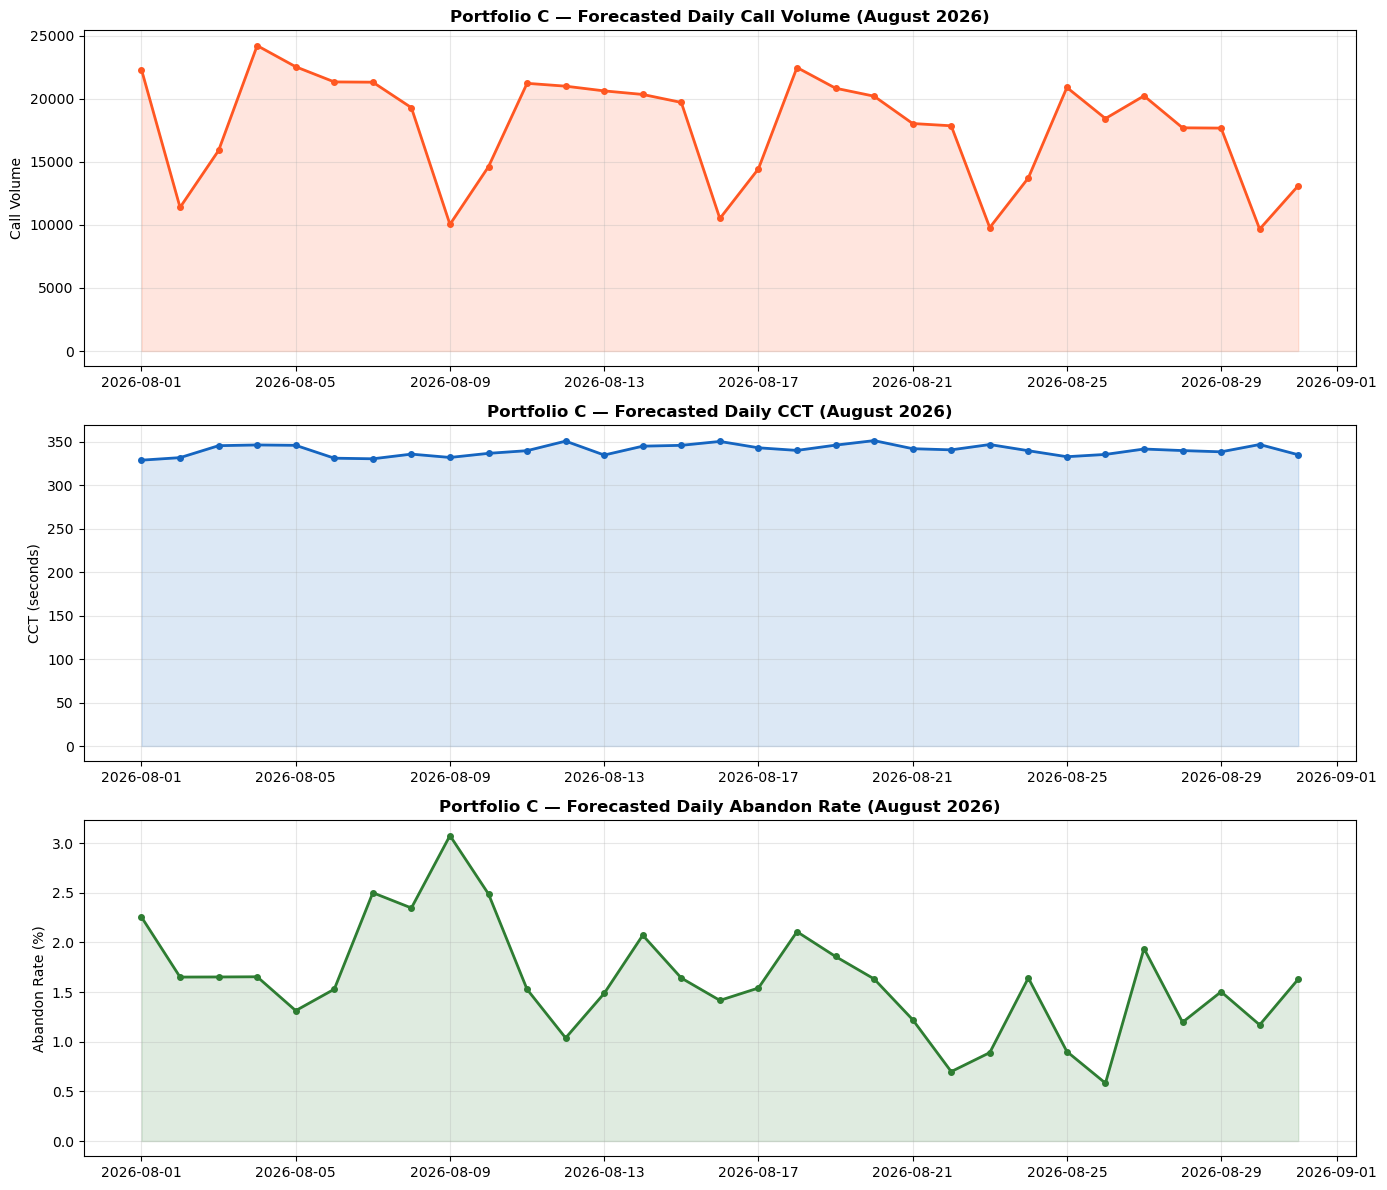

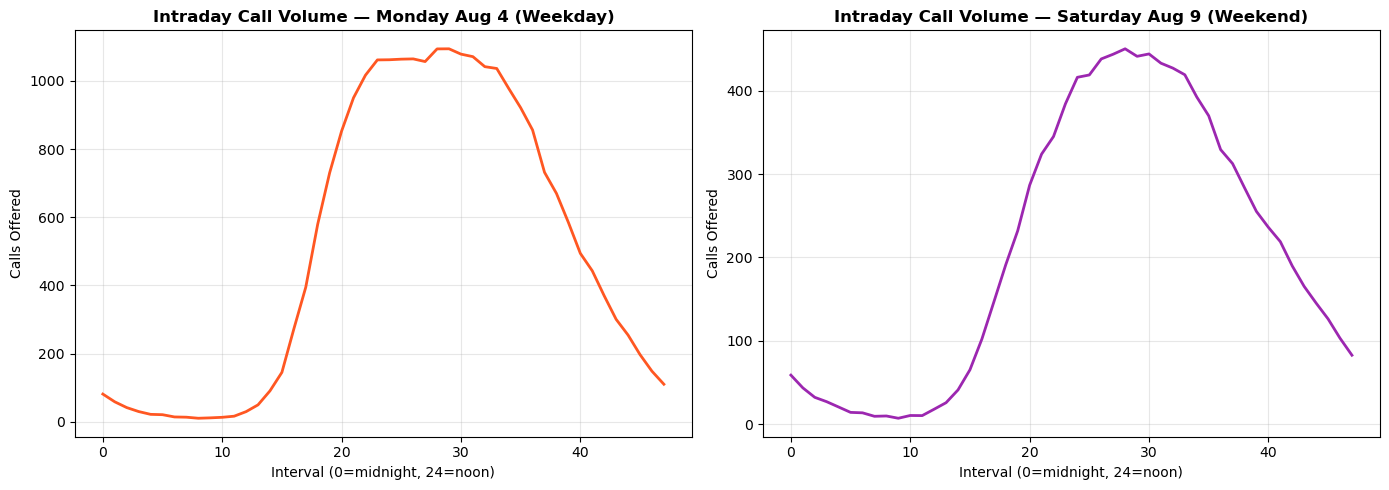

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 - Daily Call Volume
axes[0].plot(aug_daily['Date'], aug_daily['pred_cv'], color='#FF5722', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(aug_daily['Date'], aug_daily['pred_cv'], alpha=0.15, color='#FF5722')
axes[0].set_title('Portfolio C — Forecasted Daily Call Volume (August 2026)', fontweight='bold')
axes[0].set_ylabel('Call Volume')
axes[0].grid(True, alpha=0.3)

# Plot 2 - Daily CCT
axes[1].plot(aug_daily['Date'], aug_daily['pred_cct'], color='#1565C0', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(aug_daily['Date'], aug_daily['pred_cct'], alpha=0.15, color='#1565C0')
axes[1].set_title('Portfolio C — Forecasted Daily CCT (August 2026)', fontweight='bold')
axes[1].set_ylabel('CCT (seconds)')
axes[1].grid(True, alpha=0.3)

# Plot 3 - Daily Abandon Rate
axes[2].plot(aug_daily['Date'], aug_daily['pred_abd'] * 100, color='#2E7D32', linewidth=2, marker='o', markersize=4)
axes[2].fill_between(aug_daily['Date'], aug_daily['pred_abd'] * 100, alpha=0.15, color='#2E7D32')
axes[2].set_title('Portfolio C — Forecasted Daily Abandon Rate (August 2026)', fontweight='bold')
axes[2].set_ylabel('Abandon Rate (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Intraday curve for a sample weekday vs weekend ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monday Aug 4 (weekday) vs Saturday Aug 9 (weekend)
weekday = forecast_c[forecast_c['Day'] == 4].reset_index(drop=True)
weekend = forecast_c[forecast_c['Day'] == 9].reset_index(drop=True)

axes[0].plot(range(48), weekday['Calls_Offered_C'], color='#FF5722', linewidth=2)
axes[0].set_title('Intraday Call Volume — Monday Aug 4 (Weekday)', fontweight='bold')
axes[0].set_xlabel('Interval (0=midnight, 24=noon)')
axes[0].set_ylabel('Calls Offered')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(48), weekend['Calls_Offered_C'], color='#9C27B0', linewidth=2)
axes[1].set_title('Intraday Call Volume — Saturday Aug 9 (Weekend)', fontweight='bold')
axes[1].set_xlabel('Interval (0=midnight, 24=noon)')
axes[1].set_ylabel('Calls Offered')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# ── Stage 2 upgraded: interval-level model with daily total as feature ─────────

# Add predicted daily total as a feature to the interval training data
# We need the actual daily totals for Apr-Jun 2025 from df_daily
df['day_of_month'] = df['Date'].dt.day
df['month']        = df['Date'].dt.month
df['week_of_month'] = (df['day_of_month'] - 1) // 7 + 1
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_holiday']   = df['Date'].isin(pd.to_datetime(['2025-05-26', '2025-06-19'])).astype(int)

# Cyclical encodings
df['hour_sin'] = np.sin(2 * np.pi * df['IntervalIdx'] / 48)
df['hour_cos'] = np.cos(2 * np.pi * df['IntervalIdx'] / 48)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)

INTERVAL_FEATURES = [
    'IntervalIdx', 'day_of_week', 'day_of_month', 'month',
    'week_of_month', 'is_weekend', 'is_holiday',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'daily_cv'  # this is the key link from Stage 1
]

# Train on Apr+May, validate on June
train_iv = df[df['month'].isin([4, 5])].dropna(subset=INTERVAL_FEATURES)
val_iv   = df[df['month'] == 6].dropna(subset=INTERVAL_FEATURES)

interval_models = {}

for target, col in [('Call Volume', 'CV'), ('CCT', 'CCT'), ('Abandoned Rate', 'ABD')]:
    tr = train_iv.dropna(subset=[target])
    vl = val_iv.dropna(subset=[target])

    m = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05,
        max_depth=6, min_samples_leaf=20,
        random_state=42
    )
    m.fit(tr[INTERVAL_FEATURES], tr[target])

    preds = np.maximum(0, m.predict(vl[INTERVAL_FEATURES]))
    mask  = vl[target] > 0
    from sklearn.metrics import mean_absolute_percentage_error
    mape = mean_absolute_percentage_error(vl[target][mask], preds[mask]) * 100

    interval_models[target] = m
    print(f"{col} interval model — Val MAPE: {mape:.2f}%")

# ── Generate August 2026 interval forecasts ───────────────────────────────────
rows = []

for _, day_row in aug_daily.iterrows():
    dow = int(day_row['day_of_week'])
    dom = int(day_row['day_of_month'])
    wom = int((dom - 1) // 7 + 1)
    is_weekend = int(dow >= 5)
    is_holiday = 0  # no federal holidays in August 2026

    for iod in range(48):
        h = iod // 2
        m = (iod % 2) * 30

        row_features = pd.DataFrame([{
            'IntervalIdx':   iod,
            'day_of_week':   dow,
            'day_of_month':  dom,
            'month':         8,
            'week_of_month': wom,
            'is_weekend':    is_weekend,
            'is_holiday':    is_holiday,
            'hour_sin':      np.sin(2 * np.pi * iod / 48),
            'hour_cos':      np.cos(2 * np.pi * iod / 48),
            'dow_sin':       np.sin(2 * np.pi * dow / 7),
            'dow_cos':       np.cos(2 * np.pi * dow / 7),
            'daily_cv':      day_row['pred_cv'],  # Stage 1 output feeds Stage 2
        }])

        cv_pred  = max(0, interval_models['Call Volume'].predict(row_features)[0])
        cct_pred = max(0, interval_models['CCT'].predict(row_features)[0])
        abd_pred = max(0, min(1, interval_models['Abandoned Rate'].predict(row_features)[0]))

        rows.append({
            'Month':             'August',
            'Day':               dom,
            'Interval':          f"{h}:{m:02d}",
            'Calls_Offered_C':   round(cv_pred, 2),
            'Abandoned_Calls_C': round(cv_pred * abd_pred, 2),
            'Abandoned_Rate_C':  round(abd_pred, 6),
            'CCT_C':             round(cct_pred, 2),
        })

forecast_c = pd.DataFrame(rows)
print(f"\nForecast shape: {forecast_c.shape}")
print(forecast_c.head(10))

CV interval model — Val MAPE: 12.87%
CCT interval model — Val MAPE: 10.38%
ABD interval model — Val MAPE: 204.39%

Forecast shape: (1488, 7)
    Month  Day Interval  Calls_Offered_C  Abandoned_Calls_C  Abandoned_Rate_C  \
0  August    1     0:00            71.27               0.37          0.005140   
1  August    1     0:30            54.30               0.29          0.005390   
2  August    1     1:00            38.73               0.21          0.005349   
3  August    1     1:30            29.09               0.04          0.001465   
4  August    1     2:00            21.08               0.38          0.017864   
5  August    1     2:30            18.05               0.29          0.016026   
6  August    1     3:00            12.79               0.52          0.040923   
7  August    1     3:30            12.68               0.45          0.035688   
8  August    1     4:00            12.45               0.72          0.057645   
9  August    1     4:30            12.50         

In [4]:
# Only train ABD model on intervals with meaningful volume (daytime)
DAYTIME = df['IntervalIdx'].between(12, 44)  # 6am to 10pm

tr_abd = train_iv[DAYTIME.loc[train_iv.index].values].dropna(subset=['Abandoned Rate'])
vl_abd = val_iv[DAYTIME.loc[val_iv.index].values].dropna(subset=['Abandoned Rate'])

m_abd = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05,
    max_depth=6, min_samples_leaf=20,
    random_state=42
)
m_abd.fit(tr_abd[INTERVAL_FEATURES], tr_abd['Abandoned Rate'])

preds_abd = np.maximum(0, m_abd.predict(vl_abd[INTERVAL_FEATURES]))
mask_abd  = vl_abd['Abandoned Rate'] > 0
mape_abd  = mean_absolute_percentage_error(vl_abd['Abandoned Rate'][mask_abd], preds_abd[mask_abd]) * 100

interval_models['Abandoned Rate'] = m_abd
print(f"ABD interval model (daytime only) — Val MAPE: {mape_abd:.2f}%")

ABD interval model (daytime only) — Val MAPE: 210.36%


Actual Abandoned Rate stats:
count    1440.000000
mean        0.008860
std         0.023336
min         0.000000
25%         0.000000
50%         0.000000
75%         0.006725
max         0.312500
Name: Abandoned Rate, dtype: float64

Predicted Abandoned Rate stats:
count    1440.000000
mean        0.008296
std         0.007845
min         0.000000
25%         0.002341
50%         0.006534
75%         0.011267
max         0.062343
dtype: float64


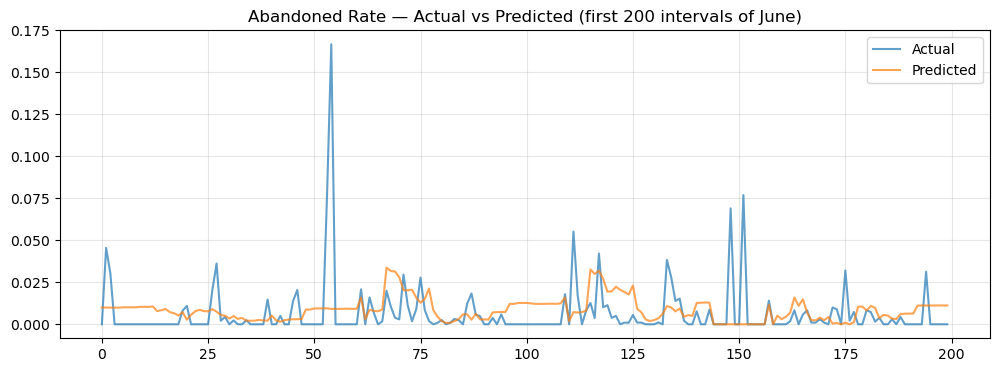

In [5]:
# Check actual vs predicted abandon rate distribution
vl_check = val_iv.dropna(subset=['Abandoned Rate', 'daily_cv'])
preds_check = np.maximum(0, interval_models['Abandoned Rate'].predict(vl_check[INTERVAL_FEATURES]))

print("Actual Abandoned Rate stats:")
print(vl_check['Abandoned Rate'].describe())
print("\nPredicted Abandoned Rate stats:")
print(pd.Series(preds_check).describe())

# Plot actual vs predicted
plt.figure(figsize=(12, 4))
plt.plot(vl_check['Abandoned Rate'].values[:200], label='Actual', alpha=0.7)
plt.plot(preds_check[:200], label='Predicted', alpha=0.7)
plt.legend()
plt.title('Abandoned Rate — Actual vs Predicted (first 200 intervals of June)')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
from export_to_template import fill_template

forecast_c['Portfolio'] = 'C'

august_intervals = forecast_c.rename(columns={
    'Calls_Offered_C':   'Call_Volume',
    'Abandoned_Calls_C': 'Abandoned_Calls',
    'Abandoned_Rate_C':  'Abandoned_Rate',
    'CCT_C':             'CCT'
})

output_df = fill_template(
    august_intervals,
    template_path='./template_forecast_v00.csv',
    output_path='./August_2026_Forecast_v00.csv'
)

FileNotFoundError: [Errno 2] No such file or directory: './template_forecast_v00.csv'

In [7]:
import os
for root, dirs, files in os.walk('/home/sagemaker-user'):
    for f in files:
        if 'template' in f.lower():
            print(os.path.join(root, f))

/home/sagemaker-user/export_to_template.py
/home/sagemaker-user/sagemaker-code-editor-server-data/extensions/amazonwebservices.aws-toolkit-vscode-3.101.0-universal/dist/src/templates/templates.json
/home/sagemaker-user/sagemaker-code-editor-server-data/extensions/amazonwebservices.aws-toolkit-vscode-3.101.0-universal/resources/smus-context-template.md
/home/sagemaker-user/sagemaker-code-editor-server-data/extensions/amazonwebservices.aws-toolkit-vscode-3.101.0-universal/resources/marketplace/cloud9/Codelens-YAML-template.png
/home/sagemaker-user/sagemaker-code-editor-server-data/extensions/amazonwebservices.aws-toolkit-vscode-3.101.0-universal/resources/walkthrough/appBuilder/AppPickerResource/CustomTemplate.png
/home/sagemaker-user/sagemaker-code-editor-server-data/extensions/ms-python.python-2026.4.0-universal/python_files/lib/jedilsp/jedi/third_party/django-stubs/django-stubs/core/checks/templates.pyi
/home/sagemaker-user/sagemaker-code-editor-server-data/extensions/ms-python.python

In [9]:
from export_to_template import fill_template

forecast_c['Portfolio'] = 'C'

august_intervals = forecast_c.rename(columns={
    'Calls_Offered_C':   'Call_Volume',
    'Abandoned_Calls_C': 'Abandoned_Calls',
    'Abandoned_Rate_C':  'Abandoned_Rate',
    'CCT_C':             'CCT'
})

output_df = fill_template(
    august_intervals,
    template_path='/home/sagemaker-user/data/template_forecast_v00.csv',
    output_path='/home/sagemaker-user/data/August_2026_Forecast_v00.csv'
)

Template loaded: 1488 rows × 19 cols

✅  Filled template saved → /home/sagemaker-user/data/August_2026_Forecast_v00.csv
   Rows: 1488  |  Expected: 1488 = 1488

   ⚠️  Null cells found:
Calls_Offered_A      1488
Abandoned_Calls_A    1488
Abandoned_Rate_A     1488
CCT_A                1488
Calls_Offered_B      1488
Abandoned_Calls_B    1488
Abandoned_Rate_B     1488
CCT_B                1488
Calls_Offered_D      1488
Abandoned_Calls_D    1488
Abandoned_Rate_D     1488
CCT_D                1488
dtype: int64


TypeError: '<' not supported between instances of 'str' and 'int'